In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [3]:
X,y=load_digits(return_X_y=True)

In [4]:
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [5]:
X.shape,y.shape

((1797, 64), (1797,))

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.shape,X_test.shape

((1203, 64), (594, 64))

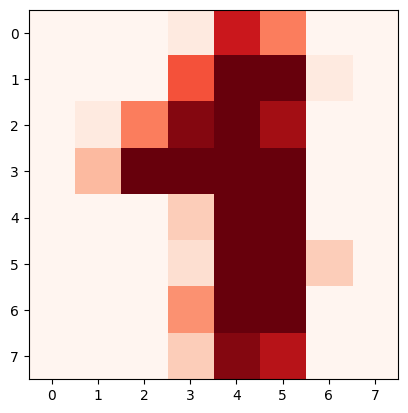

In [7]:
plt.imshow(X_train[0].reshape(8,8),cmap='Reds')
plt.show()

In [8]:
from sklearn.decomposition import PCA

In [9]:
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_test_pca=pca.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

clf=LogisticRegression()
clf.fit(X_train_pca,y_train)

y_pred=clf.predict(X_test_pca)
score=accuracy_score(y_test,y_pred)
score

0.9730639730639731

In [11]:
confusion_matrix(y_test,y_pred)

array([[55,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 52,  1,  0,  0,  0,  0,  0,  2,  0],
       [ 0,  0, 52,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1, 54,  0,  1,  0,  0,  0,  0],
       [ 0,  1,  0,  0, 63,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  0,  0, 70,  1,  0,  0,  1],
       [ 0,  0,  0,  0,  0,  1, 56,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0, 61,  0,  0],
       [ 0,  1,  0,  0,  0,  1,  0,  0, 50,  0],
       [ 0,  0,  0,  1,  0,  0,  0,  0,  2, 65]])

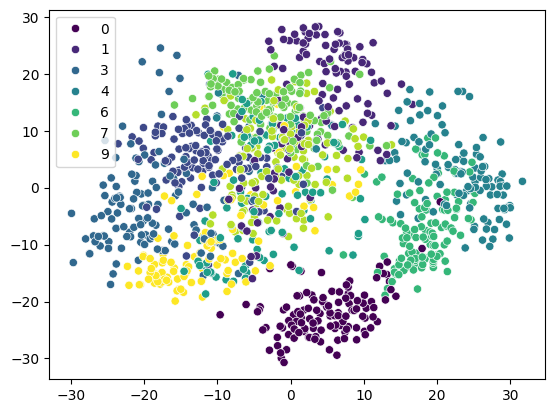

In [12]:
import seaborn as sns
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1],hue=y_train,palette='viridis')
plt.show()

In [13]:
pca = PCA(n_components=2)
X_train_pca1 = pca.fit_transform(X_train)
X_test_pca1=pca.transform(X_test)

In [14]:

lr=LogisticRegression()
lr.fit(X_train_pca1,y_train)

y_pred=lr.predict(X_test_pca1)
score=accuracy_score(y_test,y_pred)
score

C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6060606060606061

C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlxtend\plotting\decision_regions.py:352: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


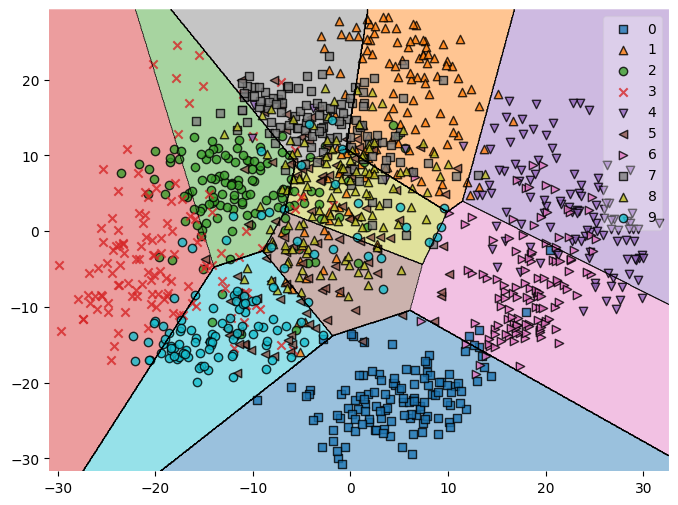

In [21]:
from mlxtend.plotting import plot_decision_regions

fig, ax = plt.subplots(figsize=(8,6))

plot_decision_regions(X=X_train_pca1,y=y_train,clf=lr,ax=ax)

plt.show()

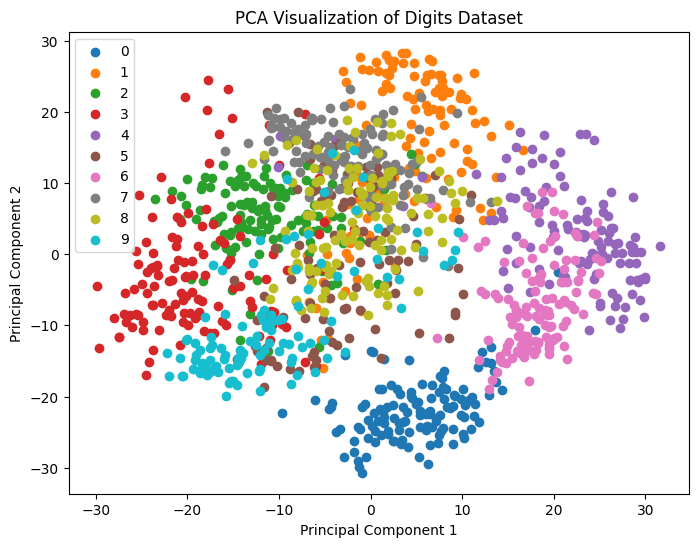

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i in range(10):          
    plt.scatter(
        X_train_pca1[y_train == i, 0],
        X_train_pca1[y_train == i, 1],
        label=i
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Digits Dataset")
plt.legend()
plt.show()